### <center> Fitting Models to Real Data </center>

Now we will consider fitting a simple SIR model to a real infection curve using the techniques learned in the previous day's materials. First, let's import some real data from a csv and design our model. 

The following code cell will extract the CSV containing the CDC's 2023-2024 influenza data. This dataset lists the total number of hospitalizations in Arizona for each day between 10/01/2023 and 04/27/2024. 

In [2]:
import pandas as pd

data = pd.read_csv('AZ_DATA.csv')

data.head()

,state,date,total_patients_hospitalized_confirmed_influenza
0,AZ,2023-10-01,14.0
1,AZ,2023-10-02,9.0
2,AZ,2023-10-03,6.0
3,AZ,2023-10-04,6.0
4,AZ,2023-10-05,6.0


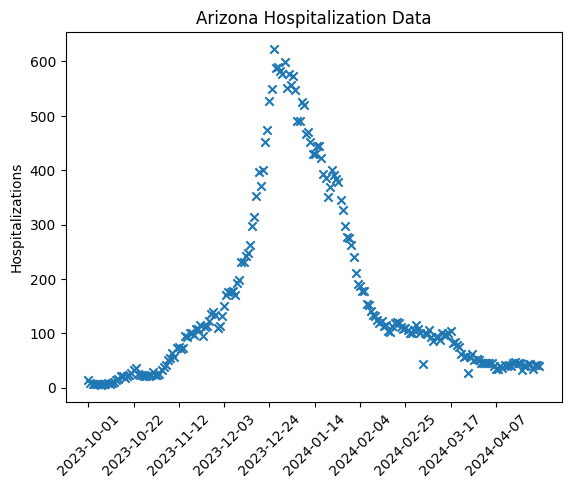

In [21]:
import matplotlib.pyplot as plt
import numpy as np

data_numpy = data['total_patients_hospitalized_confirmed_influenza'].to_numpy()

t_range = np.arange(0,len(data['date']),21)

plt.title('Arizona Hospitalization Data')
plt.ylabel('Hospitalizations')
plt.xticks(ticks = t_range, labels = data['date'].iloc[t_range], rotation=45) 
plt.scatter(np.arange(len(data['date'])),data_numpy, marker = 'x')
plt.show()

We can see that over the course of the year, Arizona's hospitalizations followed a curve similar to our SIR model experiments. There are clear deviations, but the pattern of exponential growth and exponential decay is present. 

To incorporate this data into our model we need to make a small modification. Note the structure of the SIR model, 

$$
\begin{align*}
\frac{dS}{dt} &= -\frac{\beta S I}{N} \\
\frac{dI}{dt} &= \frac{\beta S I}{N} - \gamma I \\
\frac{dR}{dt} &= \gamma I. \\
\end{align*}
$$

We have compartments corresponding to Susceptible, Infected, and Recovered but our data is actually the number of people hospitalized. There are two common approaches to incorporating hospitalization into SIR type models. The first is to develop an SIRH model, which we discussed in the Day 2 notebook. The second approach, which we will take here is to assume a proportion of the infected compartment is hospitalized at any time. Then we introduce the scale parameter $\rho$ to account for hospitalization. The full model is the SIR model together with

\begin{align*}
H = \rho I. 
\end{align*}

Our model now three parameters to identify from the data, $\beta$, $\gamma$, and $\rho$. Additionally, the number of infected individuals at time 0 is unknown and serves as another free parameter in the model. 

Let's now develop the loss function based on our discussion in the Day 2 notebook. We can express the loss function as follows

$$
\begin{align*}
\mathcal{L}(\beta,\gamma, \rho, I_{0}) = \sum\limits_{n=1}^{N}(x_{n} - \rho I(t_n;\beta,\gamma,I_{0}))^2
\end{align*}
$$

Where $n = 1,\dots,N$ enumerates each day of real data. To simplify the estimation problem we will fix $I_{0}$ and $\rho$ to values obtained from numerical optimization, so we can perform a grid search over the loss function as in the previous notebook. 

Let $\rho = 0.0014$ and $I_{0} = 3040$. The following code cell defines the model and the loss function.

In [24]:
def sir_rhs(X, params):
    S, I, R = X
    N = S + I + R
    beta, gamma = params
    dS = -beta * S * I / N
    dI = beta * S * I / N - gamma * I
    dR = gamma * I
    return np.array([dS, dI, dR])


def model(rhs, x0, ts, par):
    delta_t = ts[1] - ts[0]
    xs = np.zeros((len(ts), len(x0)))
    xs[0, :] = x0

    for t_index in range(1, len(ts)):
        x_prev = xs[t_index - 1]
        xs[t_index] = x_prev + delta_t * rhs(x_prev, par)

    return xs


def loss(par_prop, data):
    rho = 0.0014
    x0 = np.array([7_600_000.0, 3040.0, 0.0])
    delta_t = 0.01
    ts = np.arange(0, len(data), delta_t)
    sol_prop = model(sir_rhs, x0, ts, par_prop)
    return np.sum((data - rho * sol_prop[:: int(1 / delta_t), 1]) ** 2)


loss((0.3, 0.1), data_numpy)

np.float64(198768661.74489513)

Now we can perform the grid search and visualize our results. 

In [26]:
spacing = 0.01
param_range = np.arange(0, 0.5 + spacing, spacing)

B, G = np.meshgrid(param_range, param_range)
loss_vals = np.zeros(B.shape)


for i in range(len(param_range)): 
    for j in range(len(param_range)): 
        loss_vals[i, j] = loss((B[i, j], G[i, j]), data_numpy)

flat_index = np.argmin(loss_vals)
row, col = np.unravel_index(flat_index, loss_vals.shape)
best_beta = B[row, col]
best_gamma = G[row, col]
min_loss = loss_vals[row, col]

print(f"Minimum occurs at: β={best_beta:.4f}, γ={best_gamma:.4f} with value {min_loss:.4f}")

Minimum occurs at: β=0.2300, γ=0.1600 with value 579265.3501


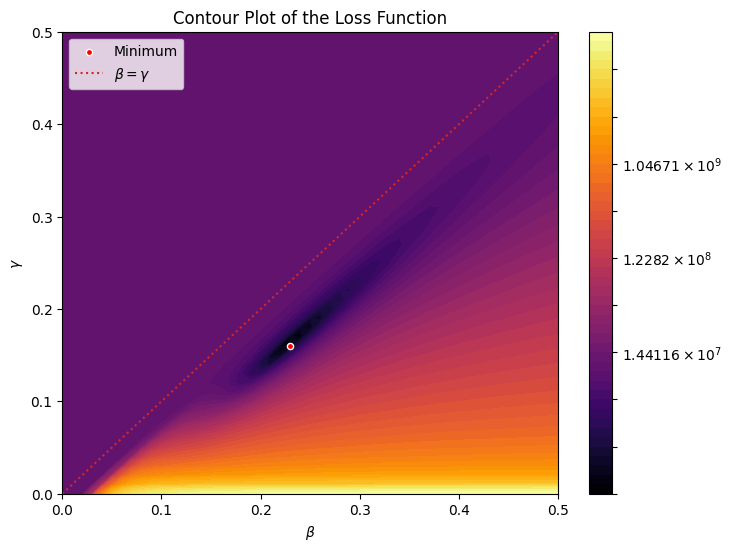

In [27]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(8, 6))

plt.contourf(B, G, loss_vals, levels=np.logspace(np.log10(loss_vals.min()), 
                                               np.log10(loss_vals.max()), 50), 
             norm=LogNorm(), cmap='inferno')

plt.colorbar()
plt.scatter(best_beta, best_gamma, color='red', edgecolors='white', s=20, label='Minimum', zorder=100)

plt.title("Contour Plot of the Loss Function")
plt.plot(param_range,param_range,color = 'tab:red',ls = 'dotted',label = "$\\beta = \\gamma$")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\gamma$")
plt.legend()
plt.show()

Finally, let's plot the solution of model with the optimal against the real data. 

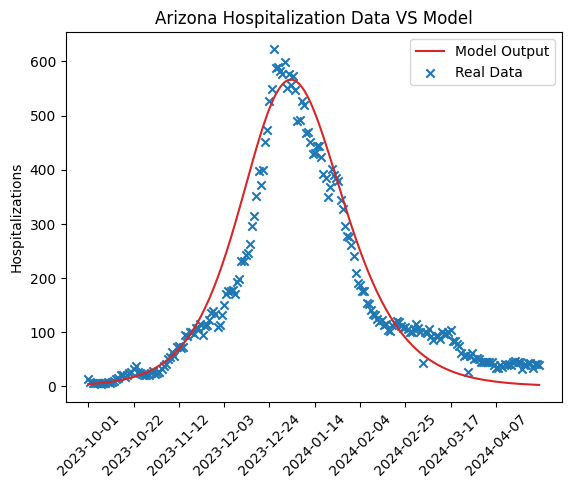

In [31]:
data_numpy = data['total_patients_hospitalized_confirmed_influenza'].to_numpy()

rho = 0.0014
t_range = np.arange(0,len(data['date']),21)
solve_range = np.arange(len(data['date']))

x0 = np.array([7_600_000., 3040.,0.])
model_output = model(sir_rhs,x0, solve_range, (0.23,0.16))

plt.title('Arizona Hospitalization Data VS Model')
plt.ylabel('Hospitalizations')
plt.xticks(ticks = t_range, labels = data['date'].iloc[t_range], rotation=45) 
plt.plot(solve_range,rho * model_output[:,1], color = 'tab:red',label = 'Model Output')
plt.scatter(solve_range,data_numpy, marker = 'x', label = 'Real Data')
plt.legend()
plt.show()